In [1]:
#importing libraries for descriptive analytics

import matplotlib.pyplot as plt 
import pandas as pd
import seaborn as sns 

In [3]:
#Downloading data frame

df = pd.read_csv("FyntraCustomerData.csv")

In [4]:
#checking data

df.head()

,Email,Address,Avatar,Avg_Session_Length,Time_on_App,Time_on_Website,Length_of_Membership,Yearly_Amount_Spent
0,mstephenson@fernandez.com,"835 Frank Tunnel\nWrightmouth, MI 82180-9605",Violet,34.497268,12.655651,39.577668,4.082621,587.951054
1,hduke@hotmail.com,"4547 Archer Common\nDiazchester, CA 06566-8576",DarkGreen,31.926272,11.109461,37.268959,2.664034,392.204933
2,pallen@yahoo.com,"24645 Valerie Unions Suite 582\nCobbborough, D...",Bisque,33.000915,11.330278,37.110597,4.104543,487.547505
3,riverarebecca@gmail.com,"1414 David Throughway\nPort Jason, OH 22070-1220",SaddleBrown,34.305557,13.717514,36.721283,3.120179,581.852344
4,mstephens@davidson-herman.com,"14023 Rodriguez Passage\nPort Jacobville, PR 3...",MediumAquaMarine,33.330673,12.795189,37.536653,4.446308,599.406092


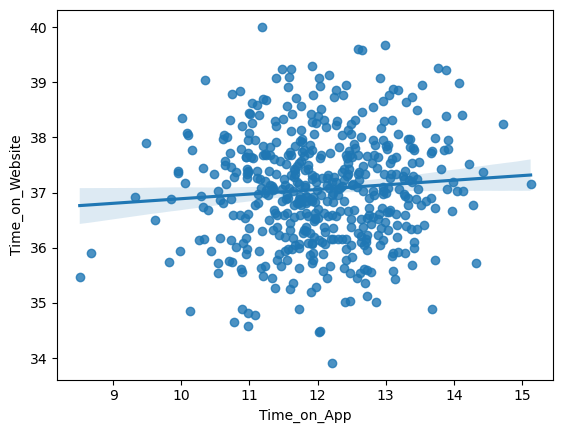

In [5]:
#Creating regression scatter plot with Time_on_App and Time_on_Website

sns.regplot (x = "Time_on_App", y = "Time_on_Website", data=df)
plt.show()

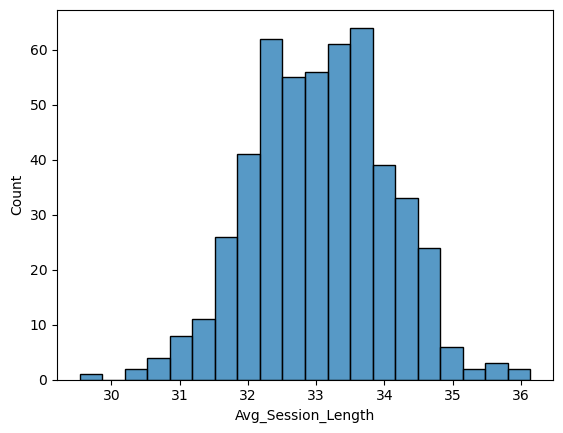

In [6]:
#Creating histogram with Avg_session_length

sns.histplot (x = "Avg_Session_Length", data = df)
plt.show()

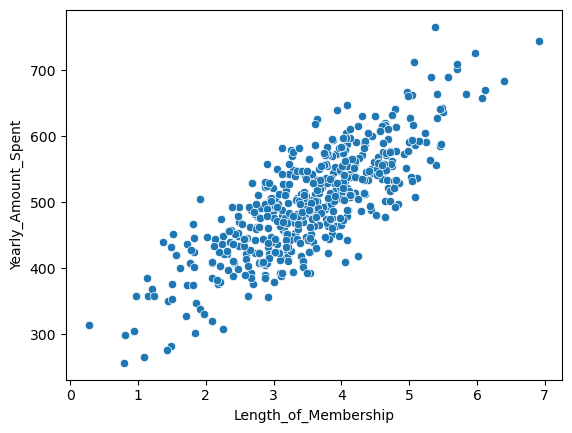

In [7]:
#Creating scatterplot with Length_of_Membership and Yearly_Amount_Spent

sns.scatterplot(x = "Length_of_Membership",y = "Yearly_Amount_Spent", data = df)
plt.show()

In [8]:
#Start of Groupby analysis

In [9]:
#importing polars library

import polars as pl

In [10]:
#changing data frame to polars and storing it into df
#checking data

df_pd = pd.read_csv("FyntraCustomerData.csv")
df = pl.from_pandas(df_pd)
df.head()

Email,Address,Avatar,Avg_Session_Length,Time_on_App,Time_on_Website,Length_of_Membership,Yearly_Amount_Spent
str,str,str,f64,f64,f64,f64,f64
"""mstephenson@fernandez.com""","""835 Frank Tunnel Wrightmouth, …","""Violet""",34.497268,12.655651,39.577668,4.082621,587.951054
"""hduke@hotmail.com""","""4547 Archer Common Diazchester…","""DarkGreen""",31.926272,11.109461,37.268959,2.664034,392.204933
"""pallen@yahoo.com""","""24645 Valerie Unions Suite 582…","""Bisque""",33.000915,11.330278,37.110597,4.104543,487.547505
"""riverarebecca@gmail.com""","""1414 David Throughway Port Jas…","""SaddleBrown""",34.305557,13.717514,36.721283,3.120179,581.852344
"""mstephens@davidson-herman.com""","""14023 Rodriguez Passage Port J…","""MediumAquaMarine""",33.330673,12.795189,37.536653,4.446308,599.406092


In [11]:
#1st groupby, High app vs low app engagement does it lead to more spending?
#finding mean of Time_on_app

(df['Time_on_App']).mean()

12.052487936928

In [12]:
#asking to go to Time_on_App column and find people below mean for Below_average and above mean for Above_average
#creating new column App_engagment
#checking data

df = df.with_columns(
    pl.when(pl.col("Time_on_App") <= 12.052487936928)
    .then(pl.lit("Below_average"))
    .otherwise(pl.lit("Above_average"))
    .alias("App_engagement")
)
df

Email,Address,Avatar,Avg_Session_Length,Time_on_App,Time_on_Website,Length_of_Membership,Yearly_Amount_Spent,App_engagement
str,str,str,f64,f64,f64,f64,f64,str
"""mstephenson@fernandez.com""","""835 Frank Tunnel Wrightmouth, …","""Violet""",34.497268,12.655651,39.577668,4.082621,587.951054,"""Above_average"""
"""hduke@hotmail.com""","""4547 Archer Common Diazchester…","""DarkGreen""",31.926272,11.109461,37.268959,2.664034,392.204933,"""Below_average"""
"""pallen@yahoo.com""","""24645 Valerie Unions Suite 582…","""Bisque""",33.000915,11.330278,37.110597,4.104543,487.547505,"""Below_average"""
"""riverarebecca@gmail.com""","""1414 David Throughway Port Jas…","""SaddleBrown""",34.305557,13.717514,36.721283,3.120179,581.852344,"""Above_average"""
"""mstephens@davidson-herman.com""","""14023 Rodriguez Passage Port J…","""MediumAquaMarine""",33.330673,12.795189,37.536653,4.446308,599.406092,"""Above_average"""
…,…,…,…,…,…,…,…,…
"""lewisjessica@craig-evans.com""","""4483 Jones Motorway Suite 872 …","""Tan""",33.23766,13.56616,36.417985,3.746573,573.847438,"""Above_average"""
"""katrina56@gmail.com""","""172 Owen Divide Suite 497 West…","""PaleVioletRed""",34.702529,11.695736,37.190268,3.576526,529.049004,"""Below_average"""
"""dale88@hotmail.com""","""0787 Andrews Ranch Apt. 633 So…","""Cornsilk""",32.646777,11.499409,38.332576,4.958264,551.620146,"""Below_average"""


In [13]:
#asking to go to App_engagment and find the average spending for Below_average and Above_average, creating average Avg_Amount_spent
#showing grouped

grouped = df.group_by("App_engagement").agg(
    pl.col("Yearly_Amount_Spent").mean().alias("Avg_Amount_Spent")
) 
grouped

App_engagement,Avg_Amount_Spent
str,f64
"""Below_average""",468.611306
"""Above_average""",533.112845


In [14]:
#2nd groupby
#fidning median of Yearly_Amount_Spent

(df['Yearly_Amount_Spent']).median()

498.88787545

In [15]:
#Asking to go to column Yearly_Amount_Spent and find people below median for Low_spending and above median for High_spending
#creating new column Overall_speding
#checking data
df = df.with_columns(
    pl.when(pl.col("Yearly_Amount_Spent") <= 498.88787545)
    .then(pl.lit("Low_spending"))
    .otherwise(pl.lit("High_spending"))
    .alias("Overall_spending")
)
df

Email,Address,Avatar,Avg_Session_Length,Time_on_App,Time_on_Website,Length_of_Membership,Yearly_Amount_Spent,App_engagement,Overall_spending
str,str,str,f64,f64,f64,f64,f64,str,str
"""mstephenson@fernandez.com""","""835 Frank Tunnel Wrightmouth, …","""Violet""",34.497268,12.655651,39.577668,4.082621,587.951054,"""Above_average""","""High_spending"""
"""hduke@hotmail.com""","""4547 Archer Common Diazchester…","""DarkGreen""",31.926272,11.109461,37.268959,2.664034,392.204933,"""Below_average""","""Low_spending"""
"""pallen@yahoo.com""","""24645 Valerie Unions Suite 582…","""Bisque""",33.000915,11.330278,37.110597,4.104543,487.547505,"""Below_average""","""Low_spending"""
"""riverarebecca@gmail.com""","""1414 David Throughway Port Jas…","""SaddleBrown""",34.305557,13.717514,36.721283,3.120179,581.852344,"""Above_average""","""High_spending"""
"""mstephens@davidson-herman.com""","""14023 Rodriguez Passage Port J…","""MediumAquaMarine""",33.330673,12.795189,37.536653,4.446308,599.406092,"""Above_average""","""High_spending"""
…,…,…,…,…,…,…,…,…,…
"""lewisjessica@craig-evans.com""","""4483 Jones Motorway Suite 872 …","""Tan""",33.23766,13.56616,36.417985,3.746573,573.847438,"""Above_average""","""High_spending"""
"""katrina56@gmail.com""","""172 Owen Divide Suite 497 West…","""PaleVioletRed""",34.702529,11.695736,37.190268,3.576526,529.049004,"""Below_average""","""High_spending"""
"""dale88@hotmail.com""","""0787 Andrews Ranch Apt. 633 So…","""Cornsilk""",32.646777,11.499409,38.332576,4.958264,551.620146,"""Below_average""","""High_spending"""


In [19]:
#asking to go to Overall_spending and find the Avg_session_length for High_spedning and Low_spending creating Total_average_session_length
#showing grouped

grouped = df.group_by("Overall_spending").agg(
    pl.col("Avg_Session_Length").mean().alias("Average_Session_Length")
)
grouped

Overall_spending,Average_Session_Length
str,f64
"""High_spending""",33.37358
"""Low_spending""",32.732807


In [20]:
# 3rd groupby, Do long-term customers spend more then short term customers?
#asking to go to column "Length_of_Membership" and split people less then 3 into short_term group, greater then 3 into long_term
#creating column memebership group
#checking data

df = df.with_columns(
    pl.when(pl.col("Length_of_Membership") <= 3)
    .then(pl.lit("Short-term"))
    .otherwise(pl.lit("Long-term"))
    .alias("Membership_Group")
)
df

Email,Address,Avatar,Avg_Session_Length,Time_on_App,Time_on_Website,Length_of_Membership,Yearly_Amount_Spent,App_engagement,Overall_spending,Membership_Group
str,str,str,f64,f64,f64,f64,f64,str,str,str
"""mstephenson@fernandez.com""","""835 Frank Tunnel Wrightmouth, …","""Violet""",34.497268,12.655651,39.577668,4.082621,587.951054,"""Above_average""","""High_spending""","""Long-term"""
"""hduke@hotmail.com""","""4547 Archer Common Diazchester…","""DarkGreen""",31.926272,11.109461,37.268959,2.664034,392.204933,"""Below_average""","""Low_spending""","""Short-term"""
"""pallen@yahoo.com""","""24645 Valerie Unions Suite 582…","""Bisque""",33.000915,11.330278,37.110597,4.104543,487.547505,"""Below_average""","""Low_spending""","""Long-term"""
"""riverarebecca@gmail.com""","""1414 David Throughway Port Jas…","""SaddleBrown""",34.305557,13.717514,36.721283,3.120179,581.852344,"""Above_average""","""High_spending""","""Long-term"""
"""mstephens@davidson-herman.com""","""14023 Rodriguez Passage Port J…","""MediumAquaMarine""",33.330673,12.795189,37.536653,4.446308,599.406092,"""Above_average""","""High_spending""","""Long-term"""
…,…,…,…,…,…,…,…,…,…,…
"""lewisjessica@craig-evans.com""","""4483 Jones Motorway Suite 872 …","""Tan""",33.23766,13.56616,36.417985,3.746573,573.847438,"""Above_average""","""High_spending""","""Long-term"""
"""katrina56@gmail.com""","""172 Owen Divide Suite 497 West…","""PaleVioletRed""",34.702529,11.695736,37.190268,3.576526,529.049004,"""Below_average""","""High_spending""","""Long-term"""
"""dale88@hotmail.com""","""0787 Andrews Ranch Apt. 633 So…","""Cornsilk""",32.646777,11.499409,38.332576,4.958264,551.620146,"""Below_average""","""High_spending""","""Long-term"""


In [21]:
#asking to go to Membership_Group column and find average spending for short_term and long_term
#showing grouped
grouped = df.group_by("Membership_Group").agg(
    pl.col("Yearly_Amount_Spent").mean().alias("Avg_Amount_Spent")
)
grouped

Membership_Group,Avg_Amount_Spent
str,f64
"""Short-term""",424.426597
"""Long-term""",527.577342


In [22]:
#Multiple linear regression model

In [23]:
#importing libraries for linear regression

import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

In [24]:
#checking data

df.head()

Email,Address,Avatar,Avg_Session_Length,Time_on_App,Time_on_Website,Length_of_Membership,Yearly_Amount_Spent,App_engagement,Overall_spending,Membership_Group
str,str,str,f64,f64,f64,f64,f64,str,str,str
"""mstephenson@fernandez.com""","""835 Frank Tunnel Wrightmouth, …","""Violet""",34.497268,12.655651,39.577668,4.082621,587.951054,"""Above_average""","""High_spending""","""Long-term"""
"""hduke@hotmail.com""","""4547 Archer Common Diazchester…","""DarkGreen""",31.926272,11.109461,37.268959,2.664034,392.204933,"""Below_average""","""Low_spending""","""Short-term"""
"""pallen@yahoo.com""","""24645 Valerie Unions Suite 582…","""Bisque""",33.000915,11.330278,37.110597,4.104543,487.547505,"""Below_average""","""Low_spending""","""Long-term"""
"""riverarebecca@gmail.com""","""1414 David Throughway Port Jas…","""SaddleBrown""",34.305557,13.717514,36.721283,3.120179,581.852344,"""Above_average""","""High_spending""","""Long-term"""
"""mstephens@davidson-herman.com""","""14023 Rodriguez Passage Port J…","""MediumAquaMarine""",33.330673,12.795189,37.536653,4.446308,599.406092,"""Above_average""","""High_spending""","""Long-term"""


In [25]:
# determing the independent vairables (X), and the dependent variable (y).

X = df[['Avg_Session_Length','Time_on_App','Time_on_Website','Length_of_Membership']]
y = df['Yearly_Amount_Spent']

In [26]:
#Splitting the model into test and train

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.3, random_state = 42)

In [27]:
#creating model

model = LinearRegression()

In [28]:
#training the model

model.fit(X_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [29]:
#predicting the test of the model

y_pred = model.predict(X_test)
y_pred

array([403.66993074, 542.57756279, 427.06591624, 502.02460418,
       410.12143558, 569.93442498, 531.93431357, 506.29651001,
       408.71870637, 473.97737102, 441.46912713, 425.33703067,
       425.12972304, 527.61676736, 431.45684042, 424.07691828,
       575.76543275, 484.8985653 , 458.35936887, 481.96502194,
       502.32441485, 513.63783571, 507.58877004, 646.57464281,
       450.24372153, 496.27043414, 556.40457802, 554.95630854,
       399.64237181, 325.84623149, 532.89783273, 478.12238679,
       501.05701852, 305.9733584 , 505.77244465, 483.79591959,
       518.83315284, 438.18241848, 456.71094212, 471.04609471,
       494.44008982, 445.31155776, 508.78802753, 501.04594195,
       488.83499651, 535.38079536, 595.20129815, 514.04714863,
       280.76758287, 433.10112339, 421.70823429, 481.23640159,
       584.71372254, 608.77480967, 563.98513435, 494.72804856,
       394.52133409, 456.41975284, 573.08767517, 499.69842395,
       512.83276999, 392.12434057, 480.05057696, 481.54

In [30]:
#evaluating the model

mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
print ("Mean squared error:", mse)
print ("R squared score:", r2)

Mean squared error: 103.91554120775197
R squared score: 0.9808757641412774


In [31]:
#Finding coefficient of independent variables and intercept of dependent variable

print("Coefficient:", model.coef_)
print("intercept:", model.intercept_)

Coefficient: [25.72425621 38.59713548  0.45914786 61.67473243]
intercept: -1050.6536743210652
